<a href="https://colab.research.google.com/github/hmmnyamminji/DL/blob/main/day02_practice3_%EB%A1%9C%EC%A7%80%EC%8A%A4%ED%8B%B1_%EB%89%B4%EB%9F%B0.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [7]:
# 로지스틱 회귀 - 뉴런 하나

import torch
import torch.nn as nn
import matplotlib.pyplot as plt

plt.rcParams["axes.unicode_minus"] = False # 마이너스 부호 깨짐 방지 설정
torch.manual_seed(42)

device = "cuda" if torch.cuda.is_available() else "cpu"

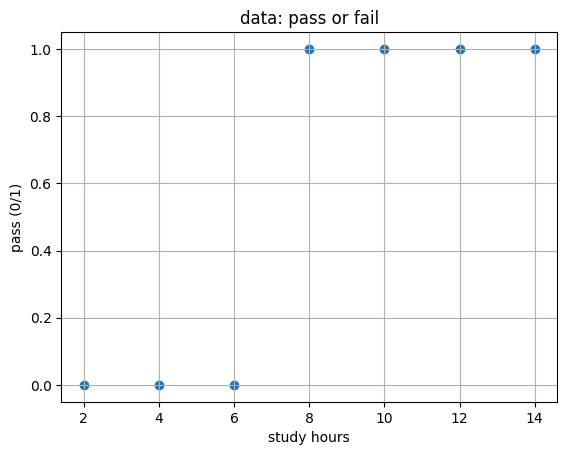

In [8]:
x = torch.tensor([[2.0],[4.0],[6.0],[8.0],[10.0],[12.0],[14.0]])
y = torch.tensor([[0.0],[0.0],[0.0],[1.0],[1.0],[1.0],[1.0]])
#                 불합격 불합격 불합격 합격  합격   합격  합격

plt.scatter(x,y)
plt.xlabel("study hours");plt.ylabel("pass (0/1)");plt.grid(True)
plt.title("data: pass or fail")
plt.savefig("plot1_passfail.png")
plt.show()
# 점들이 0 아니면 1, 계단 모양

# y = 0.1x - 0.2 회귀선을 그으면 확률의 정의를 벗어나는 값이 나온다 (합격률 120%)
# 분류 문제는 시그모이드 함수를 사용해야 한다. 왜냐하면 직선이 나타내는 범위의 결과를 0~1 사이로 구부려주기 때문이다.

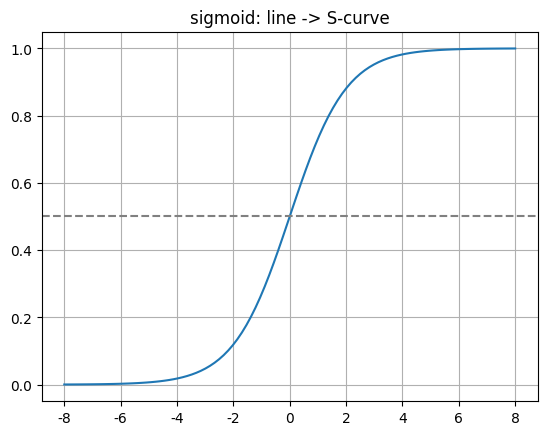

0.5를 기준으로 합격/불합격 판정


In [10]:
z = torch.linspace(-8, 8, 100)
plt.plot(z, torch.sigmoid(z))
plt.axhline(0.5, color="gray", ls="--")
plt.grid(True); plt.title("sigmoid: line -> S-curve")
plt.savefig("plot2_sigmoid.png")
plt.show()
print("0.5를 기준으로 합격/불합격 판정")

In [11]:
# 셀 3. 왜 MSE가 아니라 BCE인가
# 본류의 손실함수 = 이진 교차 엔트로피(BCE)

for p in [0.9, 0.5, 0.1, 0.01]:
  bce = -torch.log(torch.tensor(p)) # 정답이 1일 때: -log(p), 정답이 0일 때: -log(1-p)
  print(f"정답=1 인데 예측 확률 p={p:4} -> 손실 {bce.item():.2f}")

  # 핵심: '확신에 찬 오답'에 로그가 벌점을 폭탄으로 준다.

정답=1 인데 예측 확률 p= 0.9 -> 손실 0.11
정답=1 인데 예측 확률 p= 0.5 -> 손실 0.69
정답=1 인데 예측 확률 p= 0.1 -> 손실 2.30
정답=1 인데 예측 확률 p=0.01 -> 손실 4.61


In [13]:
# 셀 4. 로지스틱 회귀 모델 = 뉴런 하나
model = nn.Sequential(
    nn.Linear(1,1), # z = wx + b    (선)
    nn.Sigmoid(),   # p = σ(z)      (활성화)
).to(device)

# '뉴런(Neuron) 하나'
#   입력 ──[× w  + b]──[σ]──> 출력(0~1)
#           선형 결합    활성화

loss_fn = nn.BCELoss()
optimizer = torch.optim.Adam(model.parameters(),lr=0.1)

# 학습 루프
for epoch in range(1501):
  pred = model(x)                   # 1. 예측 (0~1 확률)
  loss = loss_fn(pred, y)           # 2. 손실 (BCE)
  optimizer.zero_grad()
  loss.backward()                   # 3. 역전파
  optimizer.step()                  # 4. 갱신
  if epoch % 300 == 0:
    print(f"epoch {epoch:4d} | BCE={loss.item():.4f}")

# 회귀 → 분류로 문제가 바뀌었는데 학습 루프는 그대로

epoch    0 | BCE=1.3588
epoch  300 | BCE=0.0817
epoch  600 | BCE=0.0443
epoch  900 | BCE=0.0280
epoch 1200 | BCE=0.0190
epoch 1500 | BCE=0.0136


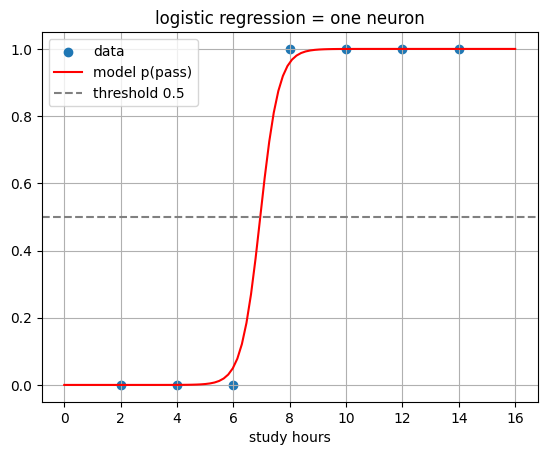

In [14]:
# 셀 5. 결과 확인 - 3차 곡선과 합격 예측
with torch.no_grad():
  x_line = torch.linspace(0, 16, 100).reshape(-1,1)
  p_line = model(x_line)


plt.scatter(x, y, label="data")
plt.plot(x_line, p_line, color="red", label="model p(pass)")
plt.axhline(0.5, color="gray", ls="--", label="threshold 0.5")
plt.xlabel("study hours"); plt.legend(); plt.grid(True)
plt.title("logistic regression = one neuron")
plt.savefig("plot3_logistic.png")
plt.show()

# 3차 곡선이 데이터를 거른다

In [15]:
# 합격 확률 예측해보기
with torch.no_grad():
  for hours in [3, 7, 9]:
    p = model(torch.tensor([[float(hours)]])).item()
    verdict = "합격" if p > 0.5 else "불합격"
    print(f"{hours:2d}시간 공부 → 합격 확률 {p:.2f} → {verdict} 예측")

 3시간 공부 → 합격 확률 0.00 → 불합격 예측
 7시간 공부 → 합격 확률 0.53 → 합격 예측
 9시간 공부 → 합격 확률 1.00 → 합격 예측
